In [1]:
%load_ext autoreload
%autoreload 2

In [105]:
import pandas as pd
from analysis_tools.workflows.evaluation_flow import evaluation_flow, evaluation_flow_zheyang
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels, annotate_labels_zheyang
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection
import pickle, sys, os


In [3]:
output_dir = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/notebooks/retrain_zheyang/compare_bdts"
os.system(f"mkdir -p {output_dir}")

0

In [4]:
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/optimize_training/")
from features_list_dict import features_list_dict

In [ ]:
df_22612_22645 = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22612-22645.h5")
df_22684_22692 = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22684-22692.h5")


In [44]:
features_list = ['Taupede_ftpMonoDiff_rlogl_value',
                'Taupede_ftp_Asymmetry_value',
                'Taupede_ftp_Distance_value',
                'Taupede_ftp_1Particles_energy',
                'Taupede_ftp_2Particles_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_zenith',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_Delay_ice_value',
                'CVStatistics_q_max_doms',
                'cscdSBU_LE_bdt_input_cscdSBU_VertexRecoDist_CscdLLh',
                'cscdSBU_MonopodFit4_noDC_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_Qtot_HLC_log_value']

In [45]:
Taupede_name = 'Taupede_ftp'
precut_dict = {'cscdSBU_MonopodFit4_noDC_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_value':('>', 10**3),
                  f'{Taupede_name}_Distance_value':[('>', 10),('<', 400)],
                  'cscdSBU_LE_bdt_input_cscdSBU_I3XYScale_noDC_value':('<', 0.9),
                  'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_22612_22645_precut = apply_selection(df_22612_22645,precut_dict)
df_22684_22692_precut = apply_selection(df_22684_22692,precut_dict)

Lets first try to evaluate Zheyang's model, apply it to his 22612_22645 training dataset
- Pre rates NuE:NuMu:NuTau=1.30 : 1.70 : 1.34
- Rates NuE:NuMu:NuTau=0.022 : 0.030 : 0.47
- Efficiency = 0.351
- ROC1=0.577, ROC2=0.754
- Finds best cuts at 0.18 and 0.55

In [46]:
model_path = "/data/user/zchen/unblinding/BDT_results/models"
with open(f'{model_path}/bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(f'{model_path}/bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.45, 'bdt2_score': 0.67}


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 26429
[weight] rate        = 1.30077
[weight] uncertainty = 0.0176719
Calculating rates for flavor: numu
Raw event count: 23320
[weight] rate        = 1.70007
[weight] uncertainty = 0.0449566
Calculating rates for flavor: nutau
Raw event count: 41639
[weight] rate        = 1.34315
[weight] uncertainty = 0.0133187


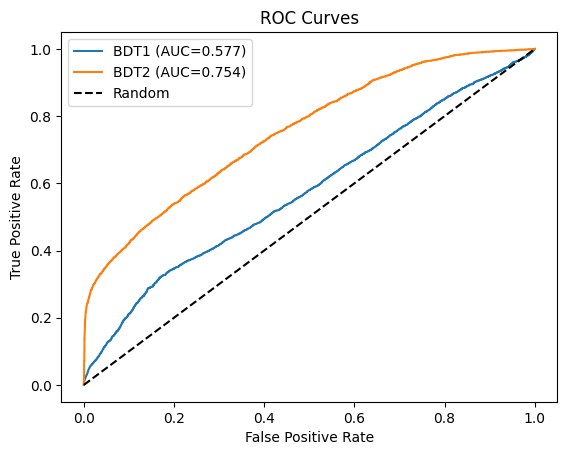

saving roc curves


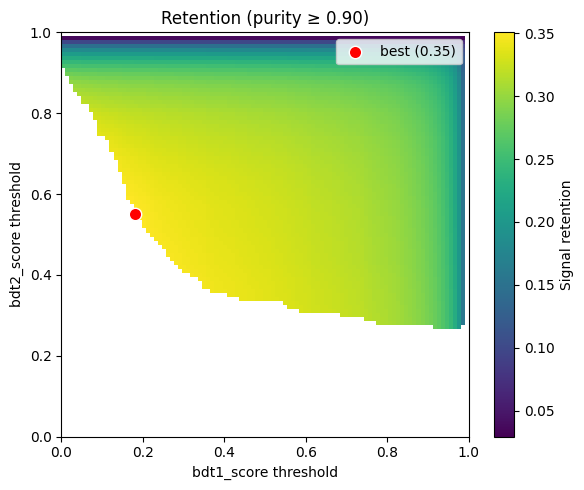


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 670
[weight] rate        = 0.0223647
[weight] uncertainty = 0.00221616
Calculating post-BDT rates for flavor: numu
Raw event count: 1686
[weight] rate        = 0.0298891
[weight] uncertainty = 0.00327692
Calculating post-BDT rates for flavor: nutau
Raw event count: 22685
[weight] rate        = 0.470903
[weight] uncertainty = 0.00669465


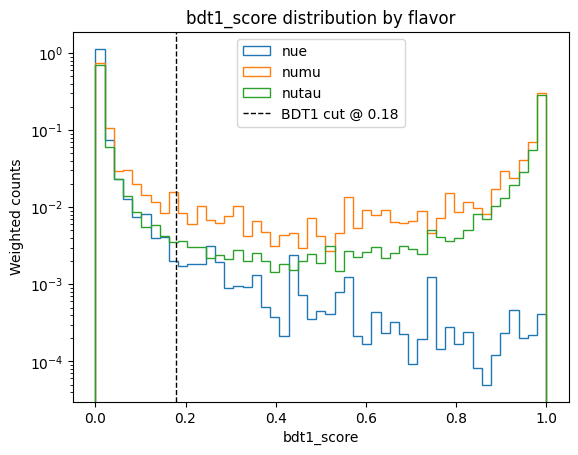

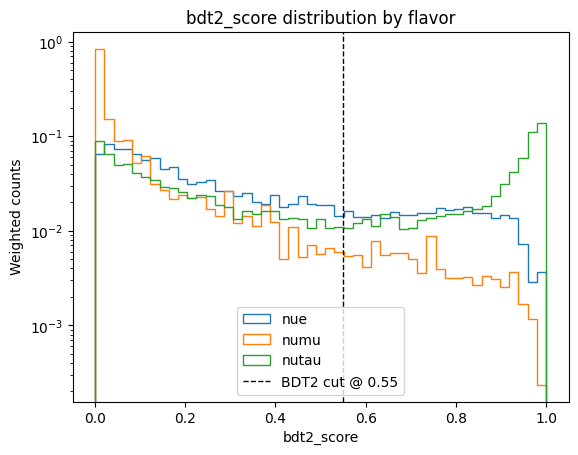

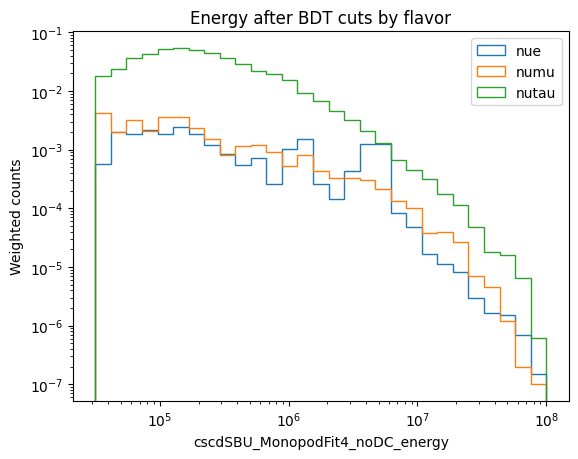


Final purity: 0.900, efficiency: 0.351


In [47]:
df_22612_22645_with_scores = prediction_flow(
    df_22612_22645_precut,
    models,
    features_list,
    thresholds=thresholds
)

summary = evaluation_flow_zheyang(
    df_22612_22645_with_scores, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria={},
    purity_target=0.90,
    output_dir=f'{output_dir}/model-zheyang_eval-22612_22645'
)

Now I apply zheyangs model to his actual evaluation dataset
- Pre rates NuE:NuMu:NuTau=2.60 : 1.75 : 1.64
- Rates NuE:NuMu:NuTau=0.017:0.04:0.52
- Efficiency = 0.313
- ROC1=0.595, ROC2=0.710
- Finds best cuts at 0.34 and 0.61


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 36970
[weight] rate        = 2.60105
[weight] uncertainty = 0.0271483
Calculating rates for flavor: numu
Raw event count: 21805
[weight] rate        = 1.75571
[weight] uncertainty = 0.0472705
Calculating rates for flavor: nutau
Raw event count: 45486
[weight] rate        = 1.64442
[weight] uncertainty = 0.0153954


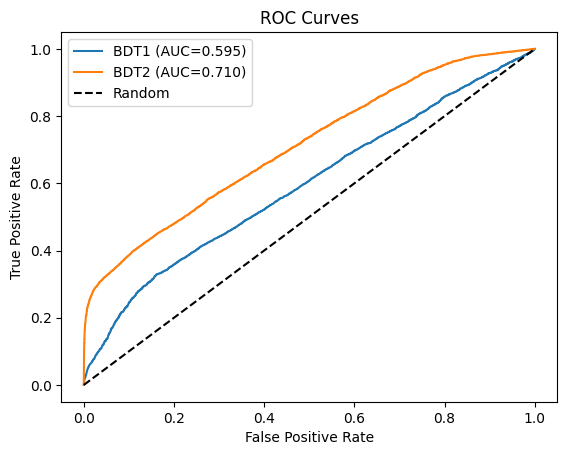

saving roc curves


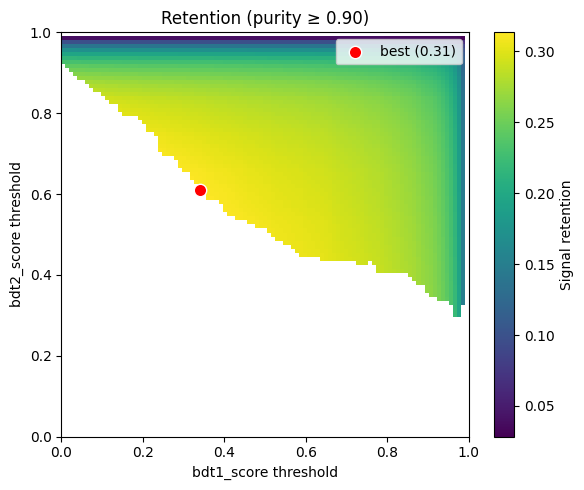


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 479
[weight] rate        = 0.0174799
[weight] uncertainty = 0.00146127
Calculating post-BDT rates for flavor: numu
Raw event count: 1811
[weight] rate        = 0.0397435
[weight] uncertainty = 0.00441757
Calculating post-BDT rates for flavor: nutau
Raw event count: 22902
[weight] rate        = 0.515439
[weight] uncertainty = 0.00708064


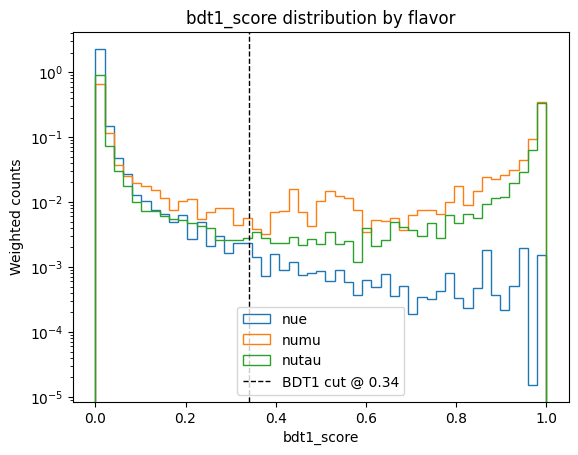

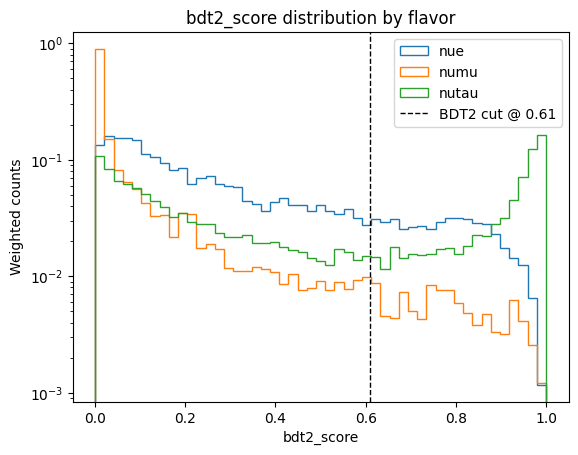

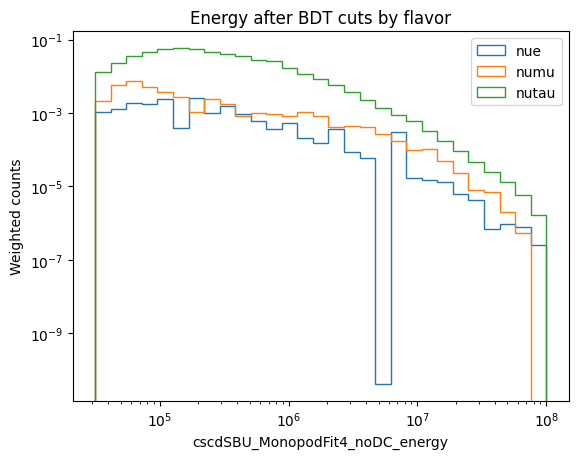


Final purity: 0.900, efficiency: 0.313


In [11]:
df_22684_22692_with_scores = prediction_flow(
    df_22684_22692_precut,
    models,
    features_list,
    thresholds=thresholds
)


summary = evaluation_flow_zheyang(
    df_22684_22692_with_scores, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria={},
    purity_target=0.90,
    output_dir=f'{output_dir}/model-zheyang_eval-22684_22692'
)

Now lets check my retrained model. Trained on 22684-22692, applied to 22612-22645.
- Pre rates: NuE:NuMu:NuTau=1.3:1.7:1.34
- Rates NuE:NuMu:NuTau=0.015:0.033:0.44
- Efficiency = 0.329
- ROC1=0.577, ROC2=0.742
- Finds best cuts at 0.34 and 0.61

In [48]:
model_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/retrain_zheyang_11features/BDT_norlogl_train_22684-22692/train_output"
with open(f'{model_path}/bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(f'{model_path}/bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.45, 'bdt2_score': 0.67}


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 26429
[weight] rate        = 1.30077
[weight] uncertainty = 0.0176719
Calculating rates for flavor: numu
Raw event count: 23320
[weight] rate        = 1.70007
[weight] uncertainty = 0.0449566
Calculating rates for flavor: nutau
Raw event count: 41639
[weight] rate        = 1.34315
[weight] uncertainty = 0.0133187


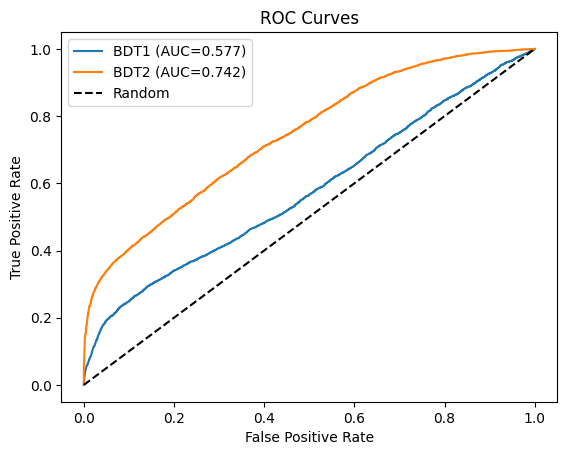

saving roc curves


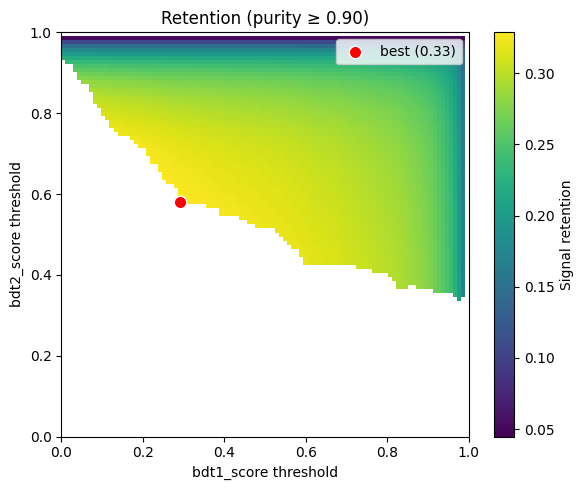


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 503
[weight] rate        = 0.015207
[weight] uncertainty = 0.00201772
Calculating post-BDT rates for flavor: numu
Raw event count: 2416
[weight] rate        = 0.0337672
[weight] uncertainty = 0.00334686
Calculating post-BDT rates for flavor: nutau
Raw event count: 21749
[weight] rate        = 0.441335
[weight] uncertainty = 0.00642334


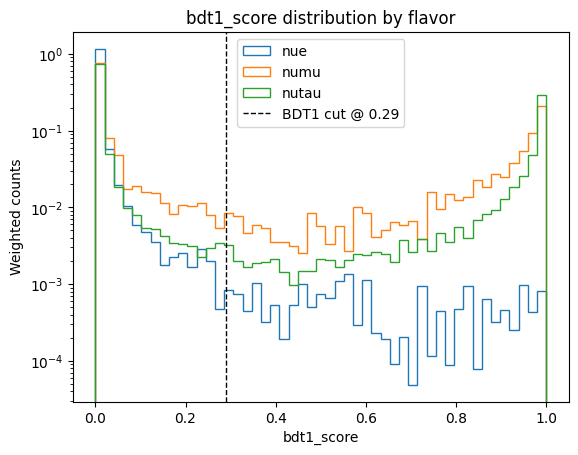

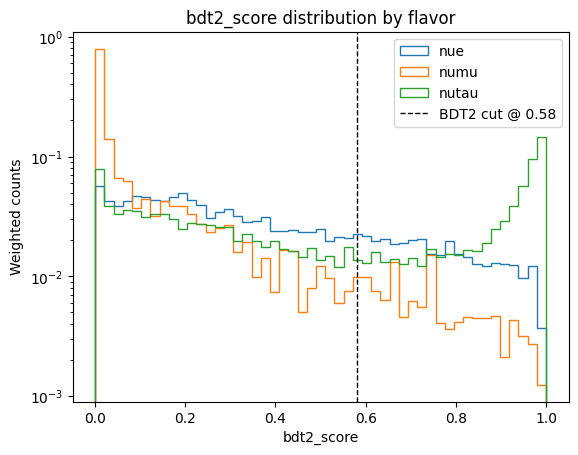

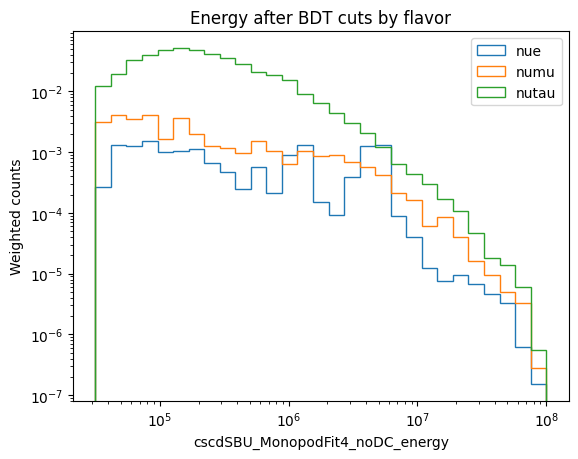


Final purity: 0.900, efficiency: 0.329


In [49]:
df_22612_22645_with_scores_retrain_22684_22692 = prediction_flow(
    df_22612_22645_precut,
    models,
    features_list,
    thresholds=thresholds
)

summary = evaluation_flow_zheyang(
    df_22612_22645_with_scores_retrain_22684_22692, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria={},
    purity_target=0.90,
    output_dir=f'{output_dir}/model-22684_22692_eval-22612_22645'
)

Now lets check my retrained model. Trained on 22612-22645, applied to 22684-22692.
- Pre rates NuE:NuMu:NuTau=2.60 : 1.75 : 1.64
- Rates NuE:NuMu:NuTau=0.017 : 0.04 : 0.52
- Efficiency = 0.313
- ROC1=0.595, ROC2=0.710
- Finds best cuts at 0.13 and 0.62

In [50]:
model_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/retrain_zheyang_11features/BDT_norlogl_train_22612-22645/train_output"
with open(f'{model_path}/bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(f'{model_path}/bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.45, 'bdt2_score': 0.67}


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 36970
[weight] rate        = 2.60105
[weight] uncertainty = 0.0271483
Calculating rates for flavor: numu
Raw event count: 21805
[weight] rate        = 1.75571
[weight] uncertainty = 0.0472705
Calculating rates for flavor: nutau
Raw event count: 45486
[weight] rate        = 1.64442
[weight] uncertainty = 0.0153954


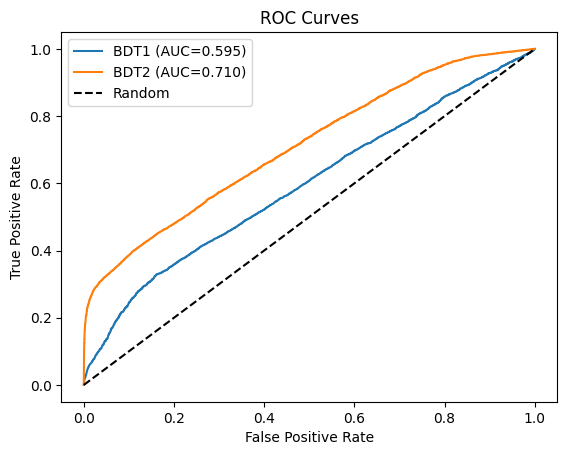

saving roc curves


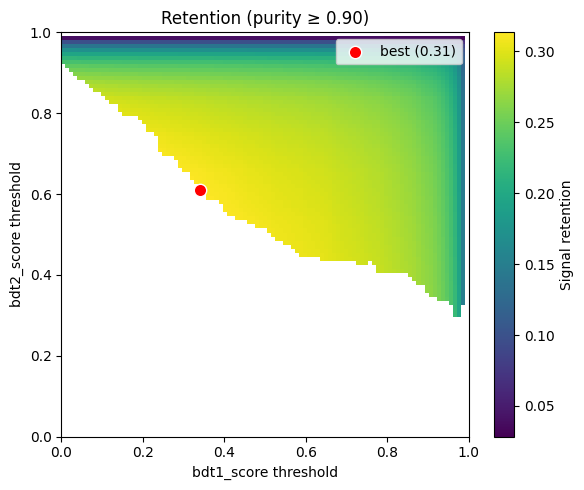


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 479
[weight] rate        = 0.0174799
[weight] uncertainty = 0.00146127
Calculating post-BDT rates for flavor: numu
Raw event count: 1811
[weight] rate        = 0.0397435
[weight] uncertainty = 0.00441757
Calculating post-BDT rates for flavor: nutau
Raw event count: 22902
[weight] rate        = 0.515439
[weight] uncertainty = 0.00708064


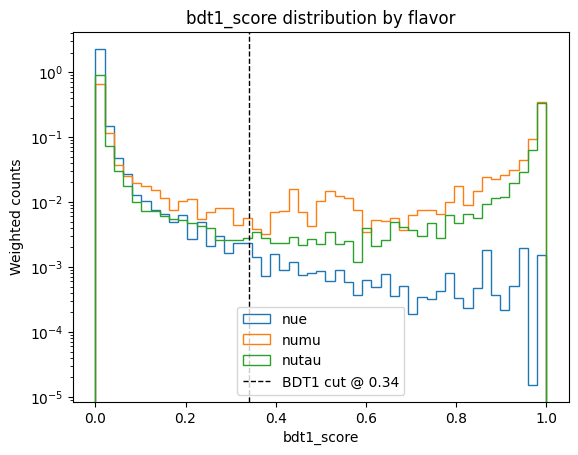

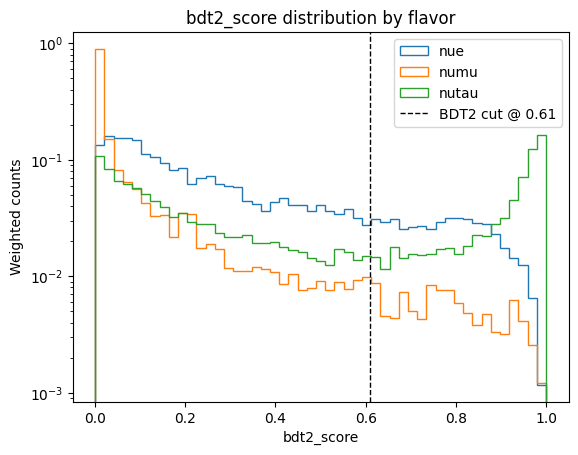

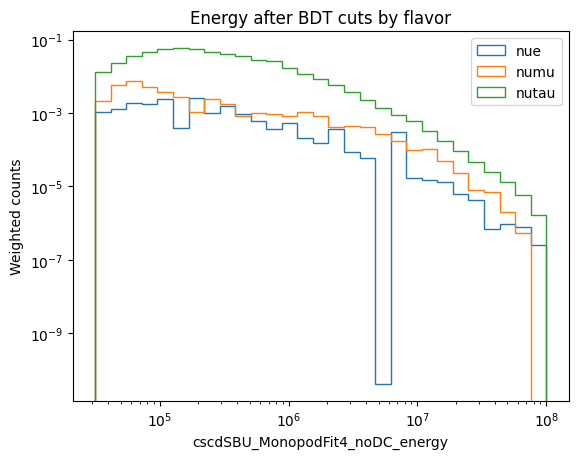


Final purity: 0.900, efficiency: 0.313


In [51]:
df_22684_22692_with_scores_retrain_22612_22645 = prediction_flow(
    df_22684_22692_precut,
    models,
    features_list,
    thresholds=thresholds
)

summary = evaluation_flow_zheyang(
    df_22684_22692_with_scores_retrain_22612_22645, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria={},
    purity_target=0.90,
    output_dir=f'{output_dir}/model-22612_22645_eval-22684_22692'
)

There is a huge difference in the rates of nue and nutau before applying the BDT. Probably something stupid with the nfiles in the weighting. Let's apply it to my own datasets

In [52]:
datasets_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/GP_globalfit/combined/SnowStorm_FTP_cscd_cascade_taureco/"

df_thijs = pd.read_parquet(f"{datasets_path}/dataset_IC86_pass2_SnowStorm_FTP_cscd_cascade_taureco_baseline.parquet")


In [36]:
for key in df_thijs.keys():print(key)

reco_dir_fit_status
reco_dir_exists
energy_monopod_fit_status
energy_monopod_exists
energy_monopod
zenith_monopod
azimuth_monopod
event_id
mjd_time_start
mjd
reco_energy_milli
reco_energy_milli_exists
reco_energy_milli_fit_status
reco_dir_milli_fit_status
reco_dir_milli
reco_dir_milli_exists
reco_length
reco_length_exists
reco_length_fit_status
FinalTopology
FinalTopology_exists
FinalEventClass
FinalEventClass_exists
TauMonoDiff_rlogl
TauMonoDiff_rlogl_exists
Taupede_Asymmetry
Taupede_Asymmetry_exists
Taupede_Distance
Taupede_Distance_exists
Taupede1_Particles_energy
Taupede1_Particles_energy_exists
Taupede2_Particles_energy
Taupede2_Particles_energy_exists
cscdSBU_MonopodFit4_noDC_zenith
cscdSBU_MonopodFit4_noDC_zenith_exists
MonopodFit_iMIGRAD_PPB0_Delay_ice
MonopodFit_iMIGRAD_PPB0_Delay_ice_exists
CVStatistics_q_max_doms
CVStatistics_q_max_doms_exists
cscdSBU_VertexRecoDist_CscdLLh
cscdSBU_VertexRecoDist_CscdLLh_exists
MonopodFit_iMIGRAD_PPB0_energy
MonopodFit_iMIGRAD_PPB0_energy_ex

In [53]:
features_thijs = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
'cscdSBU_MonopodFit4_noDC_zenith',
'MonopodFit_iMIGRAD_PPB0_Delay_ice',
'CVStatistics_q_max_doms',
'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
]

Taupede_name = 'TaupedeFit_iMIGRAD_PPB0'
cut_criteria_thijs = {'MonopodFit_iMIGRAD_PPB0_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_log':('>', 3),
                  f'Taupede_Distance':[('>', 10),('<', 400)],
                  'L4_LE_monopod_xyscale':('<', 0.9), # L4_LE_monopod_xyscale cscdSBU_I3XYScale_noDC
                  'L4_LE_monopod_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_thijs_precut = apply_selection(df_thijs,cut_criteria_thijs)

In [ ]:
model_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/retrain_zheyang_11features/BDT_norlogl_train_22684-22692/train_output"
with open(f'{model_path}/bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(f'{model_path}/bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.45, 'bdt2_score': 0.67}

In [56]:
df_thijs_22612_22645_with_scores_retrain_22684_22692 = prediction_flow(
    df_thijs_precut,
    models,
    features_thijs,
    thresholds=thresholds
)


In [71]:
per_flavor_norm = 1.8
gamma_astro = 2.52
norm_factor = 0.5 * per_flavor_norm * 1e-18
livetime = 1*365.25*24*3600
e = df_thijs_22612_22645_with_scores_retrain_22684_22692["MCPrimaryEnergy"] / 1e5
df_thijs_22612_22645_with_scores_retrain_22684_22692["weight"] = df_thijs_22612_22645_with_scores_retrain_22684_22692["fluxless_weight"] * norm_factor * e**(-gamma_astro)*livetime

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def compare_energy_distributions(
    df1,
    df2,
    name1,
    name2,
    energy_var1,
    energy_var2,
    primary_var1,
    primary_var2,
    bins=np.geomspace(10**4.5, 10**7.0, 14),
    cut_query="bdt1_score > 0.45 and bdt2_score > 0.67",
    yscale = "linear",
):

    fig, axs = plt.subplots(
        2, 2,
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1]},
        figsize=(10, 6),
    )

    flavors = [("NuE", 12, "C0"), ("NuMu", 14, "C1"), ("NuTau", 16, "C2")]

    cut1 = df1.query(cut_query)
    cut2 = df2.query(cut_query)

    panels = [
        (df1, df2, energy_var1, energy_var2, primary_var1, primary_var2, axs[:, 0]),
        (cut1, cut2, energy_var1, energy_var2, primary_var1, primary_var2, axs[:, 1]),
    ]

    rates = []

    for data1, data2, e1, e2, p1, p2, axcol in panels:

        rate1, rate2 = {}, {}
        err1, err2 = {}, {}

        for lab, pid, col in flavors:

            mask1 = abs(data1[p1]) == pid
            mask2 = abs(data2[p2]) == pid

            E1 = data1.loc[mask1, e1]
            E2 = data2.loc[mask2, e2]

            w1 = data1.loc[mask1, "weight"]
            w2 = data2.loc[mask2, "weight"]

            # histogram values
            h1, _ = np.histogram(E1, bins=bins, weights=w1)
            h2, _ = np.histogram(E2, bins=bins, weights=w2)

            # statistical errors
            e1_hist = np.sqrt(np.histogram(E1, bins=bins, weights=w1**2)[0])
            e2_hist = np.sqrt(np.histogram(E2, bins=bins, weights=w2**2)[0])

            # main spectra
            axcol[0].step(bins[:-1], h1, where="post", color=col, linestyle="-")
            axcol[0].step(bins[:-1], h2, where="post", color=col, linestyle="--")

            # error bands on spectra
            axcol[0].fill_between(
                bins[:-1],
                h1 - e1_hist,
                h1 + e1_hist,
                step="post",
                color=col,
                alpha=0.25,
            )

            axcol[0].fill_between(
                bins[:-1],
                h2 - e2_hist,
                h2 + e2_hist,
                step="post",
                color=col,
                alpha=0.15,
            )

            # ratio (no error band)
            ratio = np.divide(h2, h1, where=h1 > 0)

            axcol[1].step(
                bins[:-1],
                ratio,
                where="post",
                color=col,
                linestyle="--",
            )

            # total rates
            rate1[lab] = w1.sum()
            rate2[lab] = w2.sum()

            err1[lab] = np.sqrt((w1**2).sum())
            err2[lab] = np.sqrt((w2**2).sum())

        axcol[1].axhline(1, color="black")

        rates.append((rate1, rate2, err1, err2))

    # scales
    for ax in axs[0]:
        ax.set_yscale(yscale)
        ax.set_xscale("log")

    for ax in axs[1]:
        ax.set_xscale("log")
        ax.set_ylim(0,2)

    axs[1, 0].set_ylabel(f"{name2} / {name1}")
    axs[1, 1].set_ylabel(f"{name2} / {name1}")
    axs[1, 0].set_xlabel("Reconstructed energy")
    axs[1, 1].set_xlabel("Reconstructed energy")
    axs[0, 0].set_ylabel("Rate / year")
    axs[0, 1].set_ylabel("Rate / year")
    (r1l, r2l, e1l, e2l), (r1r, r2r, e1r, e2r) = rates

    # legends
    handles1_left = [
        Line2D([0], [0], color=col, linestyle="-",
               label=f"{lab}: {r1l[lab]:.3f} ± {e1l[lab]:.3f}")
        for lab, _, col in flavors
    ]

    handles2_left = [
        Line2D([0], [0], color=col, linestyle="--",
               label=f"{lab}: {r2l[lab]:.3f} ± {e2l[lab]:.3f}")
        for lab, _, col in flavors
    ]

    handles1_right = [
        Line2D([0], [0], color=col, linestyle="-",
               label=f"{lab}: {r1r[lab]:.3f} ± {e1r[lab]:.3f}")
        for lab, _, col in flavors
    ]

    handles2_right = [
        Line2D([0], [0], color=col, linestyle="--",
               label=f"{lab}: {r2r[lab]:.3f} ± {e2r[lab]:.3f}")
        for lab, _, col in flavors
    ]

    leg1 = axs[0, 0].legend(handles=handles1_left, title=name1, loc="lower left")
    axs[0, 0].add_artist(leg1)
    axs[0, 0].legend(handles=handles2_left, title=name2, loc="lower right")

    leg1 = axs[0, 1].legend(handles=handles1_right, title=name1, loc="lower left")
    axs[0, 1].add_artist(leg1)
    axs[0, 1].legend(handles=handles2_right, title=name2, loc="lower right")

    plt.tight_layout()

    return fig, axs

(<Figure size 1000x600 with 4 Axes>,
 array([[<Axes: ylabel='Rate / year'>, <Axes: ylabel='Rate / year'>],
        [<Axes: xlabel='Reconstructed energy', ylabel='Retrain / Zheyang'>,
         <Axes: xlabel='Reconstructed energy', ylabel='Retrain / Zheyang'>]],
       dtype=object))

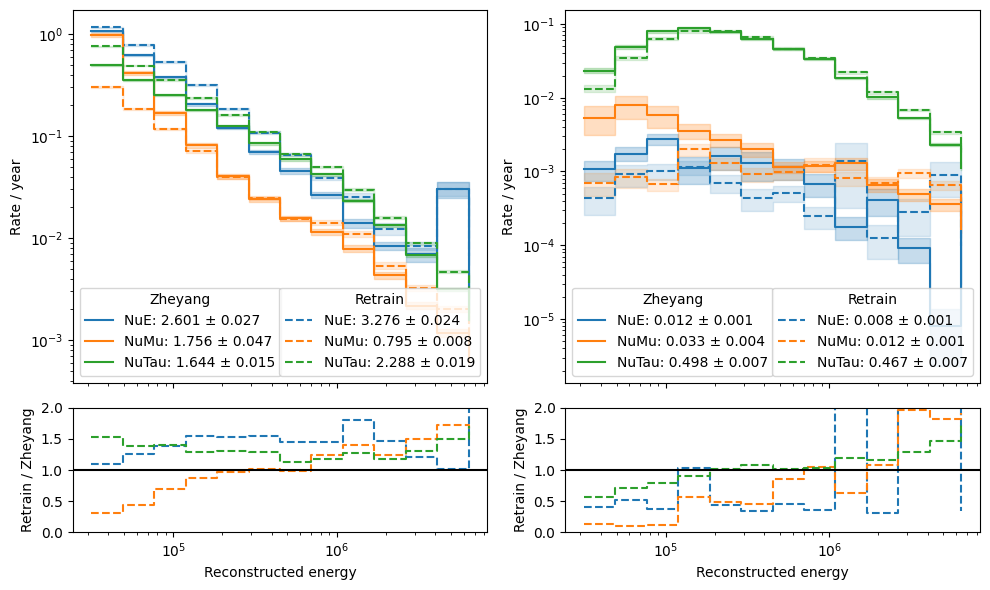

In [114]:
compare_energy_distributions(
    df_22684_22692_with_scores,
    df_thijs_22612_22645_with_scores_retrain_22684_22692,
    name1="Zheyang",
    name2="Retrain",    
    energy_var1="cscdSBU_MonopodFit4_noDC_energy",
    energy_var2="MonopodFit_iMIGRAD_PPB0_energy",
    primary_var1="cscdSBU_MCPrimary_type",
    primary_var2="MCPrimaryType",
    yscale="log"
)

compare the roc curves

In [ ]:
import matplotlib.pyplot as plt

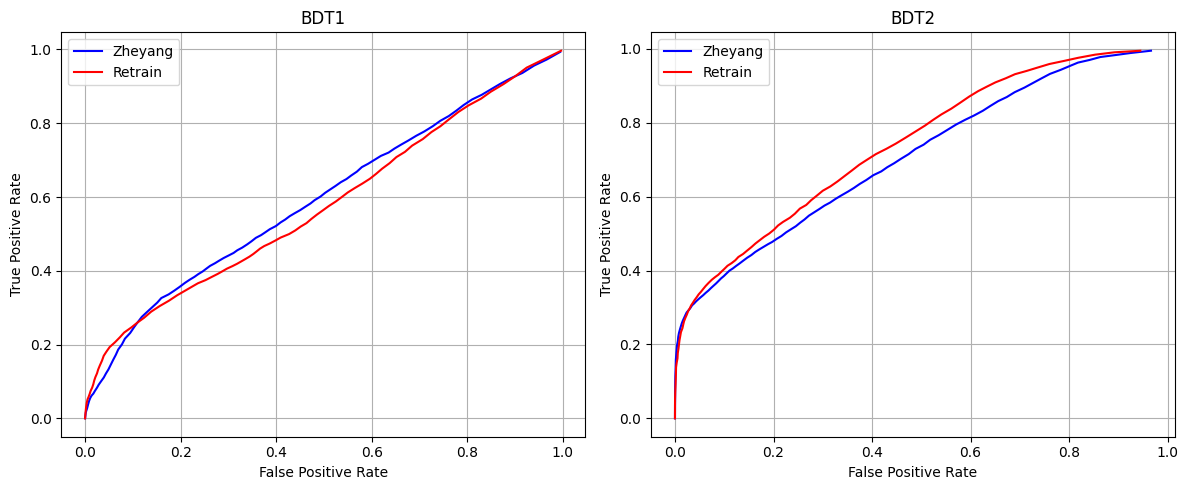

In [102]:
# Read CSVs
zheyang_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/notebooks/retrain_zheyang/compare_bdts/model-zheyang_eval-22684_22692/"
roc1_zheyang = pd.read_csv( zheyang_path + "roc_curve1.csv" )
roc2_zheyang = pd.read_csv( zheyang_path + "roc_curve2.csv" )

thijs_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/notebooks/retrain_zheyang/compare_bdts/model-22684_22692_eval-22612_22645/"
roc1_thijs = pd.read_csv( thijs_path + "roc_curve1.csv" )
roc2_thijs = pd.read_csv( thijs_path + "roc_curve2.csv" )

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot first iteration
axes[0].plot(roc1_zheyang['fpr'], roc1_zheyang['tpr'], label='Zheyang', color='blue')
axes[0].plot(roc1_thijs['fpr'], roc1_thijs['tpr'], label='Retrain', color='red')
axes[0].set_title('BDT1')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True)

# Plot second iteration
axes[1].plot(roc2_zheyang['fpr'], roc2_zheyang['tpr'], label='Zheyang', color='blue')
axes[1].plot(roc2_thijs['fpr'], roc2_thijs['tpr'], label='Retrain', color='red')
axes[1].set_title('BDT2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

They are very very comparable!

Lets create my own ROC curve

In [103]:
from sklearn.metrics import roc_curve as sk_roc_curve, auc
import numpy as np

def roc_curve_points(df, sig_label, bg_label, score_label, weight="weight"):
    y_true = np.r_[np.ones(df[sig_label].sum()), np.zeros(df[bg_label].sum())]
    y_score = np.r_[df.loc[df[sig_label], score_label].values,
                    df.loc[df[bg_label], score_label].values]
    if weight is None: 
        weights = np.ones(len(y_true))
    else:
        weights = np.r_[df.loc[df[sig_label], weight].values,
                        df.loc[df[bg_label], weight].values]
    fpr, tpr, _ = sk_roc_curve(y_true, y_score, sample_weight=weights)
    return fpr, tpr, auc(fpr, tpr)


KeyError: 'I3MCWeightDict_PrimaryNeutrinoType'

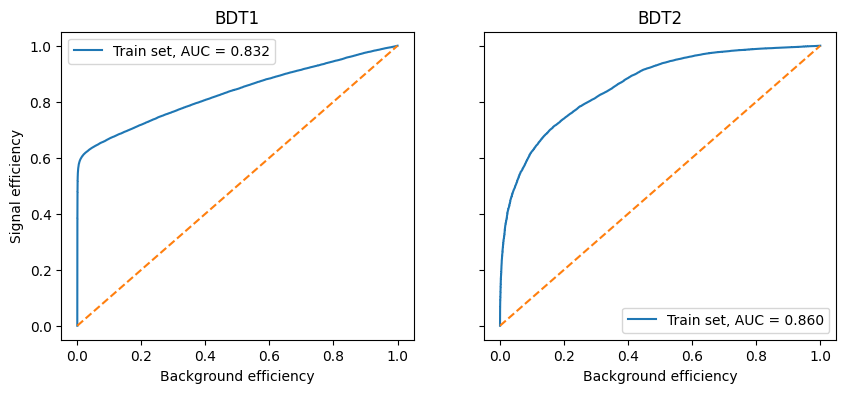

In [110]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for weight in [None]:
    for label,df_with_score in zip(["Train set", "Extra set"],[df_22684_22692_with_scores, df_thijs_22612_22645_with_scores_retrain_22684_22692]):
        try: 
            df = annotate_labels( df_with_score )
        except:
            df = annotate_labels_zheyang( df_with_score )
        fpr1, tpr1, auc1 = roc_curve_points(df, "sig_bdt1", "bg_bdt1", "bdt1_score", weight)
        axs[0].plot(fpr1, tpr1, label=f"{label}, AUC = {auc1:.3f}")
        axs[0].plot([0, 1], [0, 1], linestyle="--")
        axs[0].set_title("BDT1")
        axs[0].set_xlabel("Background efficiency")
        axs[0].set_ylabel("Signal efficiency")
        axs[0].legend()

        fpr2, tpr2, auc2 = roc_curve_points(df, "sig_bdt2", "bg_bdt2", "bdt2_score", weight)
        axs[1].plot(fpr2, tpr2, label=f"{label}, AUC = {auc2:.3f}")
        axs[1].plot([0, 1], [0, 1], linestyle="--")
        axs[1].set_title("BDT2")
        axs[1].set_xlabel("Background efficiency")
        axs[1].legend()

plt.tight_layout()
# plt.savefig(f"{output_dir}/compare_roc_train_test_set.png")
plt.show()
